In [1]:
import sys
sys.path.append('../src')

import torch
from dataset import DeepfakeDataset, get_transforms
from model import get_model
from torch.utils.data import DataLoader

DATA_DIR = "../data/raw/real_vs_fake/real-vs-fake"
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# Load dataset
train_dataset = DeepfakeDataset(DATA_DIR, split='train', transform=get_transforms('train'))
valid_dataset = DeepfakeDataset(DATA_DIR, split='valid', transform=get_transforms('valid'))

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

# Test satu batch
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")
print(f"Labels: {labels[:10]}")

# Load model
model = get_model(DEVICE)
print(f"\nModel siap di: {DEVICE}")

c:\Users\aisya\miniconda3\envs\deepfake\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
[train] Real: 50000 | Fake: 50000
[valid] Real: 10000 | Fake: 10000
Batch shape: torch.Size([32, 3, 224, 224])
Labels: tensor([1, 0, 1, 1, 0, 0, 1, 1, 0, 0])
Total params: 4,335,998
Trainable params: 4,335,998

Model siap di: cuda


In [2]:
import sys
sys.path.append('../src')
from train import train

# Mulai training
best_acc = train(
    model=model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    device=DEVICE,
    epochs=15,
    lr=1e-4,
    save_dir='../experiments'
)

Training dimulai — 15 epochs

Model device: cuda:0
Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val F1
-----------------------------------------------------------------
    1 |     0.1004 |    0.9600 |   0.0114 |  0.9962 | 0.9962
         ✓ Model tersimpan (val_acc: 0.9962)
    2 |     0.0272 |    0.9904 |   0.0071 |  0.9978 | 0.9977
         ✓ Model tersimpan (val_acc: 0.9978)
    3 |     0.0169 |    0.9938 |   0.0076 |  0.9973 | 0.9973
    4 |     0.0125 |    0.9958 |   0.0047 |  0.9985 | 0.9985
         ✓ Model tersimpan (val_acc: 0.9985)
    5 |     0.0100 |    0.9964 |   0.0040 |  0.9984 | 0.9984
    6 |     0.0063 |    0.9977 |   0.0045 |  0.9981 | 0.9981
    7 |     0.0053 |    0.9980 |   0.0070 |  0.9974 | 0.9974
    8 |     0.0045 |    0.9983 |   0.0025 |  0.9990 | 0.9989
         ✓ Model tersimpan (val_acc: 0.9990)
    9 |     0.0031 |    0.9990 |   0.0017 |  0.9993 | 0.9993
         ✓ Model tersimpan (val_acc: 0.9993)
   10 |     0.0019 |    0.9993 |   0.0015 |  0.9

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from train import evaluate
import torch.nn as nn
import torch


test_dataset = DeepfakeDataset(DATA_DIR, split='test', transform=get_transforms('valid'))
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

criterion = nn.CrossEntropyLoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load best model
checkpoint = torch.load('../experiments/best_baseline.pth')
model.load_state_dict(checkpoint['model_state_dict'])

test_loss, test_acc, test_f1, test_prec, test_rec = evaluate(model, test_loader, criterion, device)

print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test F1        : {test_f1:.4f}")
print(f"Test Precision : {test_prec:.4f}")
print(f"Test Recall    : {test_rec:.4f}")

[test] Real: 10000 | Fake: 10000


C:\Users\aisya\AppData\Local\Temp\ipykernel_7264\2624084219.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('../experiments/best_baseline.pth')


Test Accuracy  : 0.9997
Test F1        : 0.9997
Test Precision : 0.9997
Test Recall    : 0.9997


C:\Users\aisya\AppData\Local\Temp\ipykernel_7264\1802845967.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('../experiments/best_baseline.pth')


Cross-eval | Real: 1000 | Fake: 1000

Cross-Eval: StyleGAN
Accuracy  : 1.0000
F1 Score  : 1.0000
Precision : 1.0000
Recall    : 1.0000

              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      1000
        Fake       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



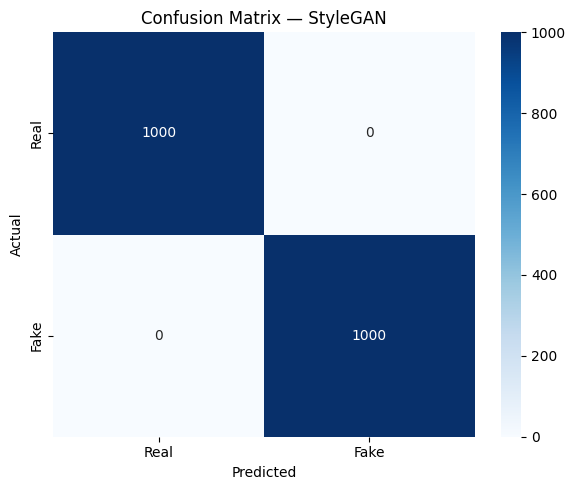

Cross-eval | Real: 1000 | Fake: 1000

Cross-Eval: HQ2024
Accuracy  : 0.4955
F1 Score  : 0.3313
Precision : 0.2489
Recall    : 0.4955

              precision    recall  f1-score   support

        Real       0.50      0.99      0.66      1000
        Fake       0.00      0.00      0.00      1000

    accuracy                           0.50      2000
   macro avg       0.25      0.50      0.33      2000
weighted avg       0.25      0.50      0.33      2000



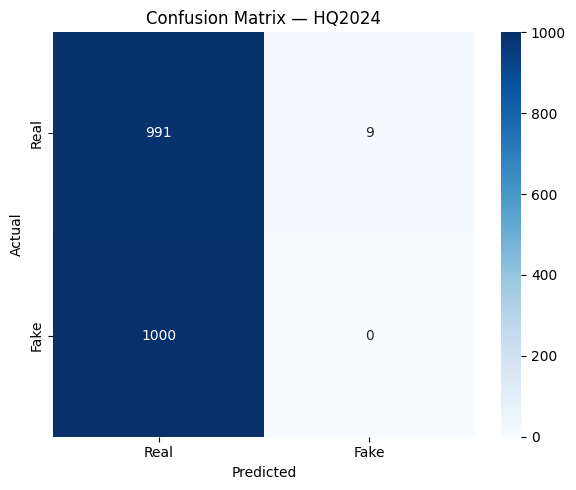


RINGKASAN CROSS-DATASET EVALUATION
Dataset         | Accuracy |       F1
----------------------------------------
140k (in-dist)  |   0.9997 |   0.9997
StyleGAN        |   1.0000 |   1.0000
HQ2024          |   0.4955 |   0.3313


In [6]:
import sys
sys.path.append('../src')
from cross_eval import run_cross_eval

# Pastikan model sudah load checkpoint terbaik
checkpoint = torch.load('../experiments/best_baseline.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Cross-eval StyleGAN
results_stylegan = run_cross_eval(
    model=model,
    real_dir='../data/raw/cross_eval/stylegan/Final Dataset/Real',
    fake_dir='../data/raw/cross_eval/stylegan/Final Dataset/Fake',
    device=DEVICE,
    dataset_name='StyleGAN',
    save_dir='../experiments'
)

# Cross-eval HQ2024
results_hq2024 = run_cross_eval(
    model=model,
    real_dir='../data/raw/cross_eval/hq2024/AI-face-detection-Dataset/real',
    fake_dir='../data/raw/cross_eval/hq2024/AI-face-detection-Dataset/AI',
    device=DEVICE,
    dataset_name='HQ2024',
    save_dir='../experiments'
)

# Ringkasan perbandingan
print("\n" + "="*50)
print("RINGKASAN CROSS-DATASET EVALUATION")
print("="*50)
print(f"{'Dataset':<15} | {'Accuracy':>8} | {'F1':>8}")
print("-"*40)
print(f"{'140k (in-dist)':<15} | {'0.9997':>8} | {'0.9997':>8}")
print(f"{'StyleGAN':<15} | {results_stylegan['acc']:>8.4f} | {results_stylegan['f1']:>8.4f}")
print(f"{'HQ2024':<15} | {results_hq2024['acc']:>8.4f} | {results_hq2024['f1']:>8.4f}")

C:\Users\aisya\AppData\Local\Temp\ipykernel_7264\2536560503.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('../experiments/best_baseline.pth')


Cross-eval | Real: 1000 | Fake: 1000


c:\Users\aisya\miniconda3\envs\deepfake\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aisya\miniconda3\envs\deepfake\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aisya\miniconda3\envs\deepfake\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 


Cross-Eval: DFDC
Accuracy  : 0.5000
F1 Score  : 0.3333
Precision : 0.2500
Recall    : 0.5000

              precision    recall  f1-score   support

        Real       0.50      1.00      0.67      1000
        Fake       0.00      0.00      0.00      1000

    accuracy                           0.50      2000
   macro avg       0.25      0.50      0.33      2000
weighted avg       0.25      0.50      0.33      2000



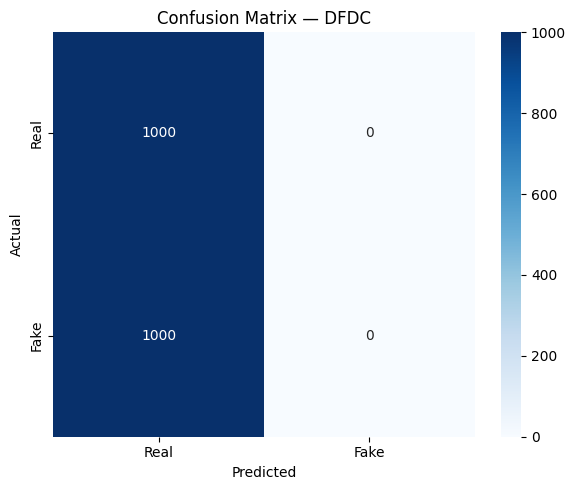

Cross-eval | Real: 1000 | Fake: 1000

Cross-Eval: Faceswap
Accuracy  : 0.5050
F1 Score  : 0.3478
Precision : 0.6402
Recall    : 0.5050

              precision    recall  f1-score   support

        Real       0.50      1.00      0.67      1000
        Fake       0.78      0.01      0.03      1000

    accuracy                           0.51      2000
   macro avg       0.64      0.51      0.35      2000
weighted avg       0.64      0.51      0.35      2000



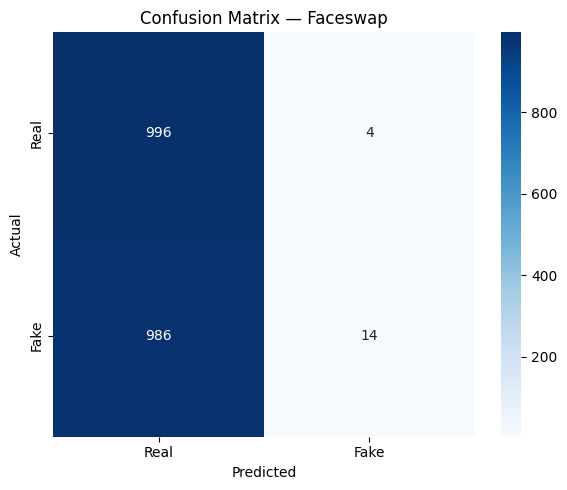


RINGKASAN LENGKAP CROSS-DATASET EVALUATION
Dataset              | Accuracy |       F1 | Keterangan
-----------------------------------------------------------------
140k (in-dist)       |   0.9997 |   0.9997 | Training distribution
DFDC                 |   0.5000 |   0.3333 | Face-swap (Facebook)
Faceswap             |   0.5050 |   0.3478 | Face-swap (diverse)


In [7]:
from cross_eval import run_cross_eval

# Pastikan model loaded
checkpoint = torch.load('../experiments/best_baseline.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Cross-eval DFDC (face-swap based, Facebook competition)
results_dfdc = run_cross_eval(
    model=model,
    real_dir='../data/raw/cross_eval/dfdc/validation/real',
    fake_dir='../data/raw/cross_eval/dfdc/validation/fake',
    device=DEVICE,
    dataset_name='DFDC',
    save_dir='../experiments'
)

# Cross-eval Faceswap
results_faceswap = run_cross_eval(
    model=model,
    real_dir='../data/raw/cross_eval/faceswap/Dataset/Test/Real',
    fake_dir='../data/raw/cross_eval/faceswap/Dataset/Test/Fake',
    device=DEVICE,
    dataset_name='Faceswap',
    save_dir='../experiments'
)

# Ringkasan akhir
print("\n" + "="*55)
print("RINGKASAN LENGKAP CROSS-DATASET EVALUATION")
print("="*55)
print(f"{'Dataset':<20} | {'Accuracy':>8} | {'F1':>8} | {'Keterangan'}")
print("-"*65)
print(f"{'140k (in-dist)':<20} | {'0.9997':>8} | {'0.9997':>8} | Training distribution")
print(f"{'DFDC':<20} | {results_dfdc['acc']:>8.4f} | {results_dfdc['f1']:>8.4f} | Face-swap (Facebook)")
print(f"{'Faceswap':<20} | {results_faceswap['acc']:>8.4f} | {results_faceswap['f1']:>8.4f} | Face-swap (diverse)")